In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [3]:
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# PACE: PLAN — define success measures and inspect the data


sns.set_theme(style="whitegrid", palette="deep")

print(f"Dataset shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing values: {df.isna().sum().sum():,}")

class_summary = (df['Class'].value_counts()
                   .rename(index={0: 'Legitimate', 1: 'Fraud'})
                   .to_frame('Transactions'))
class_summary['Percentage'] = (class_summary['Transactions'] / len(df) * 100).round(3)
class_summary

Dataset shape: 284,807 rows and 31 columns
Duplicate rows: 1,081
Missing values: 0


,Transactions,Percentage
Class,,
Legitimate,284315,99.827
Fraud,492,0.173


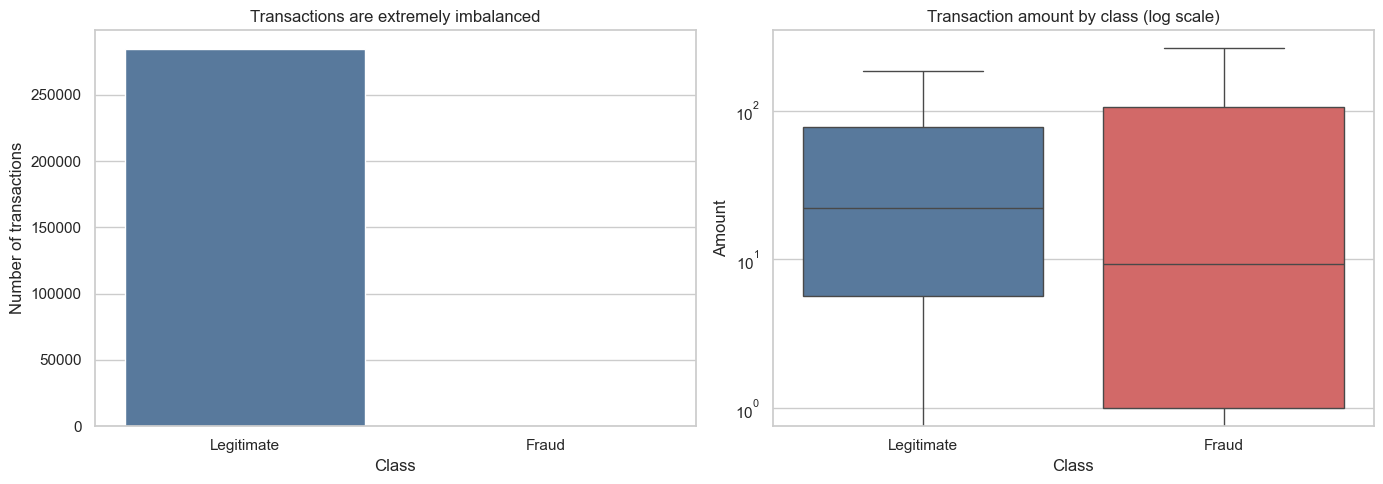

Median amount by class:
Class
Legitimate    22.00
Fraud          9.25
Name: Amount, dtype: float64


In [5]:
# PACE: ANALYSE — visualise class imbalance and payment values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Class', hue='Class', legend=False, ax=axes[0], palette=['#4C78A8', '#E45756'])
axes[0].set_xticks([0, 1], ['Legitimate', 'Fraud'])
axes[0].set_title('Transactions are extremely imbalanced')
axes[0].set_ylabel('Number of transactions')

sns.boxplot(data=df, x='Class', y='Amount', hue='Class', legend=False, ax=axes[1], palette=['#4C78A8', '#E45756'], showfliers=False)
axes[1].set_xticks([0, 1], ['Legitimate', 'Fraud'])
axes[1].set_yscale('log')
axes[1].set_title('Transaction amount by class (log scale)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

print('Median amount by class:')
print(df.groupby('Class')['Amount'].median().rename(index={0:'Legitimate', 1:'Fraud'}))

In [6]:
# PACE: CONSTRUCT — clean the data and train a cost-sensitive baseline model
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, average_precision_score, precision_recall_curve

In [7]:
# Remove exact duplicate rows before modelling
df_model = df.drop_duplicates().copy()
X = df_model.drop(columns='Class')
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [8]:
# Class weights give the rare fraud cases more influence during training
model = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]

print(f'Training transactions: {len(X_train):,}')
print(f'Test transactions: {len(X_test):,}')
print(f'Fraud rate in test data: {y_test.mean():.3%}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Training transactions: 212,794
Test transactions: 70,932
Fraud rate in test data: 0.166%

Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     70814
       Fraud       0.05      0.89      0.10       118

    accuracy                           0.97     70932
   macro avg       0.53      0.93      0.55     70932
weighted avg       1.00      0.97      0.99     70932



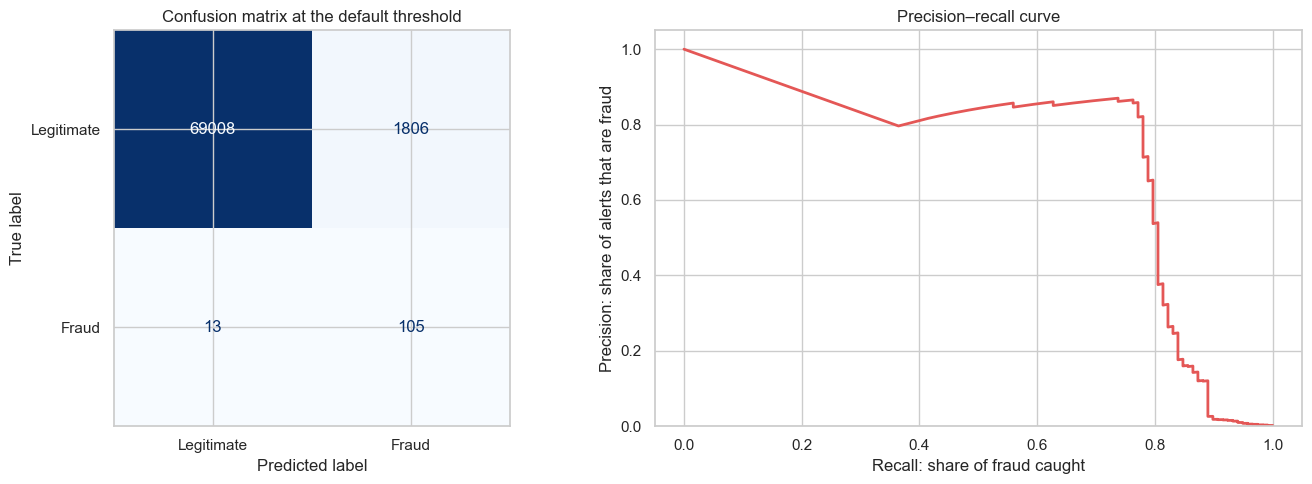

Average precision: 0.677
Fraud caught (recall): 89.0%
False alerts: 1,806
Precision: 5.5%


In [9]:
# PACE: EXECUTE — evaluate the model with fraud-focused metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Legitimate', 'Fraud'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion matrix at the default threshold')

precision, recall, thresholds = precision_recall_curve(y_test, y_score)
axes[1].plot(recall, precision, color='#E45756', linewidth=2)
axes[1].set_xlabel('Recall: share of fraud caught')
axes[1].set_ylabel('Precision: share of alerts that are fraud')
axes[1].set_title('Precision–recall curve')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

ap = average_precision_score(y_test, y_score)
tn, fp, fn, tp = __import__('sklearn').metrics.confusion_matrix(y_test, y_pred).ravel()
print(f'Average precision: {ap:.3f}')
print(f'Fraud caught (recall): {tp / (tp + fn):.1%}')
print(f'False alerts: {fp:,}')
print(f'Precision: {tp / (tp + fp):.1%}')

In [10]:
# Train and export the deployable fraud-risk model
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

In [11]:
df_model = df.drop_duplicates().copy()
X = df_model.drop(columns='Class')
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

fraud_model = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
fraud_model.fit(X_train, y_train)

model_path = 'fraud_model.joblib'
joblib.dump(fraud_model, model_path)
print(f'Model saved to: {os.path.abspath(model_path)}')
print('The model expects 30 input features: Time, V1–V28, and Amount.')

Model saved to: C:\Users\USER\fraud_model.joblib
The model expects 30 input features: Time, V1–V28, and Amount.
